# RL coursework, part IV (30 pts in total)

---

**Name:**

**SN:**

---

**Due date:** *April 10th, 2025*

---

Standard UCL policy (including grade deductions) automatically applies for any late submissions.

## How to submit

When you have completed the exercises and everything has finished running, click on 'File' in the menu-bar and then 'Download .ipynb'. This file must be submitted to Moodle named as **`<studentnumber>_RL_part4.ipynb`** before the deadline above, where `<studentnumber>` is your student number.

----
**Reminder of copyrights**

Copyrights protect this code/content and distribution or usages of it (or parts of it) without permission is prohibited. This includes uploading it and usage of it in training in any LLMs systems.

### Objectives

#### Q.1: You will implement a number of off-policy multi-step return estimates, and answer questions about their accuracy.

#### Q.2: You will be looking at other, TD-like, updates to learn the value function. You will be asked to investigate different properties of these: e.g. convergence properties, variance of updates. This is akin to a typical analysis one would undertaken when proposing a new update rule to learn value functions.


## Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

np.set_printoptions(precision=3, suppress=1)

## Section A: Multi-step + offpolicy in practice [11 points total]
For many concrete algorithms, we need to combine multi-step updates with off-policy corrections.  The multi-step updates are necessary for efficient learning, while the off-policy corrections are necessary to learn about multiple things at once, or to correct for a distribution mismatch (e.g., when trying to perform a policy-gradient update from logged data).

In this section, you will implement various different returns with off-policy corrections.  The next cell has two examples *without* corrections.  These examples compute equivalent returns, but compute those returns in different ways.  These are provided as reference implementations to help you.

Note that the implementations both allow for immediate bootstrapping on the current state value. This is unconventional (most literature only allows the first bootstrapping to happen after the first step), but we will use this convention in all implementations below for consistency.

In [ ]:
#@title On-policy return computations

def on_policy(observations, actions, pi, mu, rewards, discounts,
              trace_parameter, v_fn):
  """Compute on-policy return recursively."""
  del mu  # The policy probabilities are ignored by this function
  del pi
  T = len(rewards)  # number of transitions
  r = rewards
  d = discounts
  l = trace_parameter
  v = np.array([v_fn(o) for o in observations])
  G = np.zeros((T,))
  # recurse backwards to calculate returns
  for t in reversed(range(T)):
    # There are T+1 observations, but only T rewards, and the indexing here
    # for the rewards is off by one compared to the indexing in the slides
    # and in Sutton & Barto.  In other words, r[t] == R_{t+1}.
    if t == T - 1:
      G[t] = r[t] + d[t]*v[t + 1]
    else:
      G[t] = r[t] + d[t]*((1 - l)*v[t + 1] + l*G[t + 1])
  v = v[:-1]  # Remove (T+1)th observation before calculating the returns
  return (1 - l)*v + l*G

def on_policy_error_recursion(observations, actions, pi, mu, rewards, discounts,
                              trace_parameter, v_fn):
  del pi  # The target policy probabilities are ignored by this function
  del mu  # The behaviour policy probabilities are ignored by this function
  T = len(rewards)  # number of transitions
  r = rewards
  d = discounts
  l = trace_parameter
  v = np.array([v_fn(o) for o in observations])
  errors = np.zeros((T,))

  error = 0.
  # recurse backwards to calculate errors
  for t in reversed(range(T)):
    error = r[t] + d[t]*v[t + 1] - v[t] + d[t]*l*error
    errors[t] = error
  v = v[:-1]  # Remove (T+1)th observation before calculating the returns
  return v + l*errors

### Q 1.1 [5 points]
Implement the return functions below and run the cells below that.

In [ ]:
def full_importance_sampling(observations, actions, pi, mu, rewards, discounts, trace_parameter, v_fn):
  """
  Compute off-policy return with full importance-sampling corrections, so that
  the return G_t is corrected with the full importance-sampling correction of
  the rest of the trajectory.
  """
  # calculate uncorrected G first
  T = len(rewards)
  r = rewards
  d = discounts
  l = trace_parameter
  v = np.array([v_fn(o) for o in observations])
  G = np.zeros((T,))
  for t in reversed(range(T)):
    if t == T - 1:
      G[t] = r[t] + d[t] * v[t + 1]
    else:
      G[t] = r[t] + d[t] * ((1 - l) * v[t + 1] + l * G[t + 1])
  clipped_rhos = np.clip(pi / mu, 1.0e-6, 1.0e6)
  cum_rhos = np.cumprod(clipped_rhos[::-1])[::-1]
  v = v[:-1]
  return (1.0 - l) * v + l * cum_rhos * G

def per_decision(observations, actions, pi, mu, rewards, discounts, trace_parameter, v_fn):
  """
  Compute off-policy return with per-decision importance-sampling corrections.
  """
  T = len(rewards)
  r = rewards
  d = discounts
  l = trace_parameter
  v = np.array([v_fn(o) for o in observations])
  rhoG = np.zeros((T,))
  clipped_rhos = np.clip(pi / mu, 1.0e-6, 1.0e6)
  for t in reversed(range(T)):
    if t == T - 1:
      rhoG[t] = clipped_rhos[t] * (r[t] + d[t] * v[t + 1])
    else:
      rhoG[t] = clipped_rhos[t] * (r[t] + d[t] * ((1 - l) * v[t + 1] + l * rhoG[t + 1]))
  v = v[:-1]
  return (1.0 - l) * v + l * rhoG

def control_variates(observations, actions, pi, mu, rewards, discounts, trace_parameter, v_fn):
  """
  Compute off-policy return with
  1. per-decision importance-sampling corrections, and
  2. control variates
  """
  T = len(rewards)  # number of transitions
  r = rewards
  d = discounts
  l = trace_parameter
  v = np.array([v_fn(o) for o in observations])
  errors = np.zeros((T,))
  clipped_rhos = np.clip(pi / mu, 1.0e-6, 1.0e6)
  error = 0.0
  # recurse backwards to calculate errors
  for t in reversed(range(T)):
    error = (r[t] + d[t]*v[t + 1] - v[t] + d[t]*l*error) * clipped_rhos[t]
    errors[t] = error
  v = v[:-1]  # Remove (T+1)th observation before calculating the returns
  return v + l*errors

def adaptive_bootstrapping(observations, actions, pi, mu, rewards, discounts, trace_parameter, v_fn):
  """
  Compute off-policy return with
  1. per-decision importance-sampling corrections, and
  2. control variates, and
  3. adaptive bootstrapping.

  Implement the adaptive bootstrapping with an *additional* trace parameter
  lambda, such that lambda_t = lambda * min(1, 1/rho_t).
  """
  T = len(rewards)  # number of transitions
  rho = pi / mu
  r = rewards
  d = discounts
  l = trace_parameter * np.minimum(1.0, 1.0 / rho)
  v = np.array([v_fn(o) for o in observations])
  errors = np.zeros((T,))
  clipped_rhos = np.clip(pi / mu, 1.0e-6, 1.0e6)
  error = 0.
  # recurse backwards to calculate errors
  for t in reversed(range(T)):
    error = (r[t] + d[t]*v[t + 1] - v[t] + d[t]*error) * clipped_rhos[t] * l[t]
    errors[t] = error
  v = v[:-1]  # Remove (T+1)th observation before calculating the returns
  return v + errors

In [ ]:
#@title (Run, don't modify) Functions to generate experience, compute values
MU_RIGHT = 0.5
PI_RIGHT = 0.9
NUMBER_OF_STEPS = 5
DISCOUNT = 0.99

def generate_experience():
  r"""Generate experience trajectories from a tabular tree MDP.

  This function will start in state 0, and will then generate actions according
  to a uniformly random behaviour policy.  When A_t == 0, the action will be to
  the left, with A_t==1, it will be to the right.  The states are nunmbered as
  depicted below:
          0
         / \
        1   2
       / \ / \
      3   4   5
         ...

  Args:
      number_of_steps: the number of total steps.
      p_right: probability of the behaviour to go right.

  Returns:
      A dictionary with elements:
        * observations (number_of_steps + 1 integers): the
          observations are just the actual (integer) states
        * actions (number_of_steps integers): actions per step
        * rewards (number_of_steps scalars): rewards per step
        * discounts (number_of_steps scalars): currently always 0.9,
          except the last one which is zero
        * mu (number_of_steps scalars): probability of selecting each
          action according to the behavious policy
        * pi (number_of_steps scalars): probability of selecting each
          action according to the target policy (here p(1) = 0.9 and
          p(0) = 0.1, where a==1 implies we go 'right')
  """
  # generate actions
  actions = np.array(np.random.random(NUMBER_OF_STEPS,) < MU_RIGHT,
                     dtype=int)
  s = 0
  # compute resulting states
  states = np.cumsum(np.arange(1, NUMBER_OF_STEPS + 1) + actions)
  states = np.array([0] + list(states))  # add start state

  # in this case, observations are just the real states
  observations = states

  # generate rewards
  rewards     = 2.*actions - 1. # -1 for left, +1 for right,
  rewards[-1] = np.sum(actions)  # extra final reward for going right

  # compute discounts
  discounts     = DISCOUNT * np.ones_like(rewards)
  discounts[-1] = 0.  # final transition is terminal, has discount=0

  # determine target and behaviour probabilities for the selected actions
  pi = np.array([1. - PI_RIGHT, PI_RIGHT])[actions] # Target probabilities
  mu = np.array([1. - MU_RIGHT, MU_RIGHT])[actions] # Behaviour probabilities

  return dict(observations=observations,
              actions=actions,
              pi=pi,
              mu=mu,
              rewards=rewards,
              discounts=discounts)

def true_v(s, pi, number_of_steps):
  """Compute true state value recursively."""
  depth = int(np.floor((np.sqrt(1 + 8*s) - 1)/2))
  position = int(s - depth*(depth+1)/2)
  remaining_steps = number_of_steps - depth
  final_reward = DISCOUNT**(remaining_steps-1)*(position + pi*remaining_steps)
  reward_per_step = pi*(+1) + (1 - pi)*(-1)
  discounted_steps = (1 - DISCOUNT**(remaining_steps - 1))/(1 - DISCOUNT)
  reward_along_the_way = reward_per_step * discounted_steps
  return reward_along_the_way + final_reward



[ 19.12  734.542 218.231   6.324   0.709]


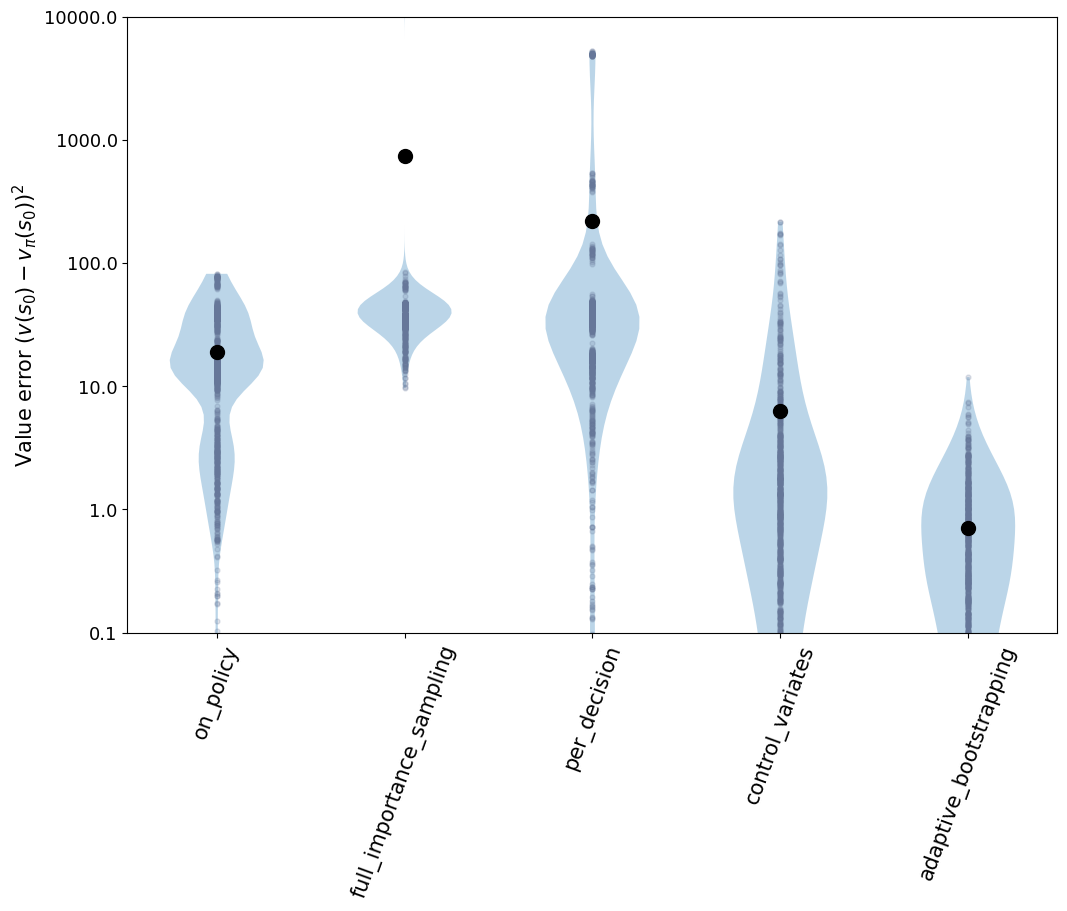

In [ ]:
#@title Run experiment (don't modify)
algs = ['on_policy', 'full_importance_sampling', 'per_decision', 'control_variates', 'adaptive_bootstrapping']

# Precompute state values (for efficiency)
N = NUMBER_OF_STEPS
true_vs = [true_v(s, PI_RIGHT, N) for s in range((N+1)*(N+2)//2)]

def random_v(iteration, s):
  rng = np.random.RandomState(seed=s + iteration*10000)
  return true_vs[s] + rng.normal(loc=0, scale=1.)  # Add fixed random noise

def plot_errors(ax, errors):
  errors = np.array(errors)
  ax.violinplot(np.log10(errors), showextrema=False)
  ax.plot(range(1, len(algs)+1), np.log10(errors).T,
          '.', color='#667799', ms=7, alpha=0.2)
  ax.plot(range(1, len(algs)+1), np.log10(np.mean(errors, axis=0)),
          '.', color='#000000', ms=20)
  ax.set_yticks(np.arange(-2, 5))
  ax.set_yticklabels(10.**np.arange(-2, 5), fontsize=13)
  ax.set_ylabel("Value error $(v(s_0) - v_{\\pi}(s_0))^2$", fontsize=15)
  ax.set_xticks(range(1, len(algs)+1))
  ax.set_xticklabels(algs, fontsize=15, rotation=70)
  ax.set_ylim(-1, 4)

fig = plt.figure(figsize=(12, 8))

errors = []
estimates = []
v0 = true_vs[0]
for iteration in range(1000):
  errors.append([])
  estimates.append([])
  trajectory = generate_experience()
  for alg in algs:
    estimate = eval(alg)(**trajectory,
                        v_fn=lambda s: random_v(iteration, s),
                        trace_parameter=0.9)
    errors[-1].append((estimate[0] - v0)**2)
print(np.mean(errors, axis=0))
plot_errors(plt.gca(), errors)

Above, the distributions of mean squared value errors are shown, with the mean as a big black dot and the (1,000) individual return samples as small black dots.

### Q 1.2 [3 points]
Explain the ranking in terms of value error of the different return estimates.

The ranking is (from best to worst):
1. adaptive bootstrapping + control variates + per-decision
2. control variates + per-decision
3. on policy
4. per-decision
5. full importance sampling

- Per-decision method has lower variance than full importance sampling. This is due to that in full importance sampling, we apply $\rho_{t:T-1}$ to all rewards while in per-decision case we apply $\rho_{t:k}$ to reward $R_{k+1}$. In other words, in full importance sampling case, the rewards are scaled by more product terms. Given $\mathbb{E}[\rho_k] = 1$ and we assume independence of each $\rho_k$ and they have same variance, we have $\text{V}(\rho_{t:T}) = \mathbb{E}\left[\prod_{k=t}^{T-1}\rho_k^2\right] - \left(\mathbb{E}\left[\prod_{k=t}^{T-1}\rho_k\right]\right)^2 = \prod_{k=t}^{T-1}\mathbb{E}\left[\rho_k^2\right] - \prod_{k=t}^{T-1}\mathbb{E}\left[\rho_k\right]^2 = \left(\text{V}\left(\rho\right) + 1\right)^{T-t} - 1$. So the variance for full importance sampling is much larger than per-decision given it has much more terms.
- With control variate and per-decision sampling, we have lower variance than per-decision sampling only. Control variate has lower variance by centering around the value function as it uses TD error instead of raw return. $v(S_t)$ usually has positive correlation with TD error which serves as a control variate to reduce the variance.
- With adaptive bootstrapping additionally, the variance can be further reduced. By choosing $\text{min}(1, 1/\rho_t)$ as adaptive coefficient, we stablise the sum of error if we are too off-policy.
- To compare the variance of on policy, we can treat it as the case of $\rho_t = 1, \forall t$. So $\text{V}(\rho_{t:T})$ = 0. That's why on policy has lower variance than per-decision importance sampling.



### Q 1.3 [3 points]
Could there be a reason to **not** choose the best return according to this ranking when learning off-policy?  Explain your answer.

Adpative bootstrapping method introduces biased estimate. We may also truncate the trace too aggressively when $\rho_t$ is large (policy diverge), making the estimator close to TD(0) case and potentially missing long-term dependencies. There is also exploration-exploitation trade-off, clipping large $\rho_t$ reduces exploration, which stabilises the estimates but leads to premature convergence to a suboptimal policy.

## Section B: Potential different algorithms/updates [19 points total]
 Consider a MDP $M = (\mathbb{S}, \mathbb{A}, p, r, \gamma)$ and a behaviour policy $\mu$. We use policy $\mu$ to generate trajectories of experience:
\begin{equation*}
    (s_{t}, a_{t}, r_{t},s_{t+1}, a_{t+1}, r_{t+1},\cdots, s_{t+n-1}, a_{t+n-1}, r_{t+n-1}, s_{t+n}, a_{t+n}) \,.
\end{equation*}
Note that this is an $n$-step sequence, starting from time $t$.

Given these partial trajectories we consider the following learning problems:




### Q2.1 [9 points]
Consider a learning update based on the following temporal difference error:
$$\delta_t = R(S_t, A_t) + \gamma R(S_{t+1}, A_{t+1}) + \gamma^2 \max_a q(S_{t+2}, a) - q(S_t, A_t)$$

Consider updating a tabular action value function with TD.

i) Does the resulting value function converge, under any initialisation of the value function? Consider an appropiate learning rate (Robbins–Monro conditions). If so, prove the convergence under infinity number of interactions with this MDP, under fixed behaviour policy $\mu$ and show its convergence point. If not, show why it diverges. (7 points)

ii) Under which conditions, would the above process converge to the optimal value function $q_*$ ? (2 points)

i)

Given the temporal difference error:
$$ \delta_t = R(S_t, A_t) + \gamma R(S_{t+1}, A_{t+1}) + \gamma^2 \max_a q(S_{t+2}, a) - q(S_t, A_t), $$
we update a tabular action-value function $q(S_t, A_t)$ using the TD update:
$$ q(S_t, A_t) \leftarrow q(S_t, A_t) + \alpha_t \delta_t, $$
where $\alpha_t$ satisfies the Robbins-Monro conditions ($\sum_t \alpha_t = \infty$, $\sum_t \alpha_t^2 < \infty$). We aim to prove that this update converges under any initialization of $q$, with an infinite number of interactions in the MDP under a fixed behavior policy $\mu$, and to find the convergence point.

Define the operator $T_Q$ based on the TD error:
$$ (T_Q f)(s, a) = R(s, a) + \mathbb{E} \left[ \gamma R(S_{t+1}, A_{t+1}) + \gamma^2 \max_{a'} f(S_{t+2}, a') \mid S_t = s, A_t = a \right], $$
where $S_{t+1} \sim P(\cdot \mid s, a)$, $A_{t+1} \sim \mu(\cdot \mid S_{t+1})$, and $S_{t+2} \sim P(\cdot \mid S_{t+1}, A_{t+1})$. The TD update can be seen as a stochastic approximation of the fixed-point iteration $q \leftarrow T_Q q$.

We need to show that $T_Q$ is a contraction in the max norm. For two functions $u, v$, compute:
$$ (T_Q u)(s, a) - (T_Q v)(s, a) = \mathbb{E} \left[ \gamma R(S_{t+1}, A_{t+1}) + \gamma^2 \max_{a'} u(S_{t+2}, a') \mid S_t = s, A_t = a \right] - \mathbb{E} \left[ \gamma R(S_{t+1}, A_{t+1}) + \gamma^2 \max_{a'} v(S_{t+2}, a') \mid S_t = s, A_t = a \right]. $$
$$ = \gamma^2 \mathbb{E} \left[ \max_{a'} u(S_{t+2}, a') - \max_{b'} v(S_{t+2}, b') \mid S_t = s, A_t = a \right]. $$

Thus:
$$\left| (T_Q u)(s, a) - (T_Q v)(s, a) \right| = \gamma^2 \left|\mathbb{E} \left[ \max_{a'} u(S_{t+2}, a') - \max_{b'} v(S_{t+2}, b') \mid S_t = s, A_t = a \right]\right|$$
$$\leq \gamma^2 \left| \max_{s', a'} u(s', a') - \max_{s', b'} v(s', b')\right| \leq \gamma^2 \max_{s', a'}\left|u(s',a') - v(s', a')\right|, $$
since the expectation is over a probability distribution so it is smaller than maximum and:
$$ \left| \max_x f(x) - \max_y g(y) \right| \leq \max_x \left|f(x) - g(x)\right|.$$

Taking the max norm:
$$ \| T_Q u - T_Q v \|_\infty \leq \gamma^2 \max_{s', a'} \left| u(s', a') - v(s', a') \right| = \gamma^2 \| u - v \|_\infty, $$
Thus, $T_Q$ is a $\gamma^2$-contraction ($\gamma^2 < 1$ since $\gamma \in [0, 1)$), and by the Banach fixed-point theorem, $T_Q$ has a unique fixed point $q^\mu$.

The TD update is:
$$ q_{t+1}(S_t, A_t) = q_t(S_t, A_t) + \alpha_t \left( R(S_t, A_t) + \gamma R(S_{t+1}, A_{t+1}) + \gamma^2 \max_a q_t(S_{t+2}, a) - q_t(S_t, A_t) \right). $$
Define the noise term:
$$ \eta_t = \left( R(S_t, A_t) + \gamma R(S_{t+1}, A_{t+1}) + \gamma^2 \max_a q_t(S_{t+2}, a) \right) - (T_Q q_t)(S_t, A_t). $$
Then the update becomes:
$$ q_{t+1}(S_t, A_t) = q_t(S_t, A_t) + \alpha_t \left( (T_Q q_t)(S_t, A_t) + \eta_t - q_t(S_t, A_t) \right). $$

$\mathbb{E}[\eta_t \mid S_t, A_t] = 0$, since:

$$ \mathbb{E}[\eta_t \mid S_t, A_t] = \mathbb{E} \left[ R(S_t, A_t) + \gamma R(S_{t+1}, A_{t+1}) + \gamma^2 \max_a q_t(S_{t+2}, a) \mid S_t, A_t \right] - (T_Q q_t)(S_t, A_t) = 0. $$

Assume rewards are bounded, $|R(s, a)| \leq R_{\text{max}} < \infty$, then we have:
$$\|q^\mu\|_\infty \leq R_{\text{max}} + \gamma R_{\text{max}} + \gamma^2\|q^\mu\|_\infty.$$

Then the fixed point $q^\mu$ of $T_Q$ is bounded:

$$ \| q^\mu \|_\infty \leq \frac{R_{\text{max}} (1 + \gamma)}{1 - \gamma^2}. $$
Since $q_t \to q^\mu$, and updates involve bounded terms, $q_t$ remains bounded, say $|q_t(s, a)| \leq Q_{\text{max}}$ for some $Q_{\text{max}} \geq \frac{R_{\text{max}} (1 + \gamma)}{1 - \gamma^2}$. Thus:
$$ \left| R(S_t, A_t) + \gamma R(S_{t+1}, A_{t+1}) + \gamma^2 \max_a q_t(S_{t+2}, a) \right| \leq R_{\text{max}} + \gamma R_{\text{max}} + \gamma^2 Q_{\text{max}}, $$
$$ \left| (T_Q q_t)(S_t, A_t) \right| \leq R_{\text{max}} + \gamma R_{\text{max}} + \gamma^2 Q_{\text{max}}, $$
$$ |\eta_t| \leq 2 (R_{\text{max}} + \gamma R_{\text{max}} + \gamma^2 Q_{\text{max}}) < \infty. $$

So $|\eta_t|$ is uniformly bounded.

The policy $\mu$ ensures all state-action pairs are visited infinitely often (e.g., $\mu(a \mid s) > 0$ for all $s, a$).

Under these conditions (Robbins-Monro $\alpha_t$, bounded noise, infinite visits), the TD update converges to the fixed point $q^\mu$ of $T_Q$ (Tsitsiklis, 1994).

The fixed point $q^\mu$ satisfies:
$$ q^\mu(s, a) = R(s, a) + \mathbb{E} \left[ \gamma R(S_{t+1}, A_{t+1}) + \gamma^2 \max_{a'} q^\mu(S_{t+2}, a') \mid S_t = s, A_t = a \right]. $$
The state-value function $V(s) = \sum_a \mu(a \mid s) q(s, a)$ converges to $V^\mu(s) = \sum_a \mu(a \mid s) q^\mu(s, a)$.

The TD update converges to $q^\mu$, and $V$ converges to $V^\mu$, under any initialization of $q$.

---

ii)

When $\mu = \pi^*$, the above process converges to optimal value function $q^*$.

Proof:
For optimal action-value function $q^*$, it satisfies Bellman Optimality Operator $T^*$:
$$(T^*f)(s, a) = R(s, a) + \mathbb{E}\left[\gamma \max_{a'} f(S_{t+1}, a') \mid S_t = s, A_t = a \right].$$
The optimal policy $\pi^*$ is greedy with respect to $q^*$, i.e.,
$$\pi^*(s) = \arg \max_a q^*(s, a).$$

Since we have

$$
q^\mu(s, a) = (T_Q q^\mu)(s,a) = R(s, a) + \mathbb{E} \left[ \gamma R(S_{t+1}, A_{t+1}) + \gamma^2 \max_{a'} q^\mu(S_{t+2}, a') \mid S_t = s, A_t = a \right]$$

$$
= R(s, a) + \gamma \sum_{s'} P(s' \mid s, a) \sum_{a'} \mu(a' \mid s') R(s', a')
+ \gamma^2 \sum_{s'} P(s' \mid s, a) \sum_{a'} \mu(a' \mid s') \sum_{s''} P(s'' \mid s', a') \max_{a''} q^\mu(s'', a'')
$$

If $\mu$ is the optimal policy $\pi^*$, i.e. $\mu(a \mid s) = 1$ for $a = \arg\max_{a'} q^*(s, a')$,  
then we apply operator $T_Q$ on $q^*$:

$$
(T_Q q^*)(s, a) = R(s, a) + \gamma \sum_{s'} P(s' \mid s, a) R(s', \arg\max_{a'} q^*(s', a'))
$$

$$
+ \gamma^2 \sum_{s'} P(s' \mid s, a) \sum_{s''} P(s'' \mid s', \arg\max_{a'} q^*(s', a'))
q^*(s'', \arg\max_{a''} q^*(s'', a''))
$$

$$
= R(s, a) + \gamma \sum_{s'} P(s' \mid s, a)
\left( R(s', \arg\max_{a'} q^*(s', a'))
+ \gamma \sum_{s''} P(s'' \mid s', \arg\max_{a'} q^*(s', a'))
q^*(s'', \arg\max_{a''} q^*(s'', a'')) \right)
$$

$$
= R(s, a) + \gamma \sum_{s'} P(s' \mid s, a)
\left( T^* q^*(s', a') \right)
\quad (\text{where } T^* \text{ is the Bellman optimality operator.})
$$

$$
= R(s, a) + \gamma \sum_{s'} P(s' \mid s, a) \max_{a'} q^*(s', a')
$$

$$
= q^*(s, a) \quad (\text{since } q^* \text{ is the unique fixed point of Bellman optimality operator.})
$$

This indicates $q^*$ is the unique fixed point of $T_Q$. So we conclude $T_Q$ converges to optimal action value function, provided that $\mu$ is the optimal policy $\pi^*$.


### Q2.2 [10 points]

Consider the same questions now for the following temporal difference error
\begin{equation}
        \delta_t = r(S_{t},A_{t}) + \gamma \frac{\pi(A_{t+1}|S_{t+1})}{\mu(A_{t+1}|S_{t+1})} \left[ r(S_{t+1},A_{t+1}) + \gamma \max_{a} q(S_{t+2},a) \right] - q(S_t, A_t)
\end{equation}

where $\pi(a|s) \in \arg\max_a q(s,a), \forall s,a \in \mathbb{A} \times \mathbb{S}$ and consider the behaviour policy to be either:

  a. $\mu(a|s) \in \arg\max_a q(s,a), \forall s,a \in \mathbb{A} \times \mathbb{S}$,
  
  b. $\mu(a|s) = \frac{1}{|\mathbb{A}|}$ (uniformly random policy).

Answer the below two questions for **both choices** of the behaviour policy $\mu$:
* i)  Does updating a tabular action value function with this TD error converge to the optimal value function $q_*$? Consider an appropiate learning rate (Robbins–Monro conditions). If so, prove this convergence under infinity number of interaction with this MDP, under behaviour policy $\mu$. If not, show why it diverges or alternatively convergence to a different solution. (4 points)
* ii) How does the variance of this update compare to the one induced by the error in Q2.1? (3 points).
* iii) Can you propose a different behaviour policy that achieves a lower variance than any of the choices we considered for $\mu$ (a and b)? Prove that your behaviour policy achieve this. Argue why, if that is not possible. (3 points)

i)

We rigorously define $\pi(a\mid s) \in \arg\max_a q(s,a)$. When there is a tie in $\arg\max$, the policy will randomly choose among the $\arg\max$ with uniform probability. Same definition applies to $\mu(a\mid s) \in \arg\max_a q(s,a)$.

$\pi$ is the greedy policy.

For choice a, $\mu = \pi$ by our definition so the ratio cancels, which degenerates to Q2.1. In Q2.1 ii) we have already proved when $\mu = \pi^*$, the process converges to $q^*$.

For choice b,

Define the operator $T_Q$ based on the TD error and apply $q^*$:
$$ (T_Q q^*)(s, a) = R(s, a) + \gamma \mathbb{E}_{\mu, p} \left[ \frac{\pi(A_{t+1}|S_{t+1})}{\mu(A_{t+1}|S_{t+1})} \left( R(S_{t+1}, A_{t+1}) + \gamma \max_{a'} q^*(S_{t+2}, a')\right) \mid S_t = s, A_t = a \right]$$
$$= R(s, a) + \gamma \sum_{s'} P(s' \mid s, a) \sum_{a'} \pi(a' \mid s') R(s', a') + \gamma^2 \sum_{s'} P(s' \mid s, a) \sum_{a'} \pi(a' \mid s') \sum_{s''} P(s'' \mid s', a') \max_{a''} q^*(s'', a'')$$
$$=R(s, a) + \gamma \sum_{s'} P(s' \mid s, a) R(s', \arg \max_{a'}q^*(s', a')) + \gamma^2 \sum_{s'} P(s' \mid s, a) \sum_{s''} P(s'' \mid s', \arg \max_{a'}q^*(s', a')) \max_{a''} q^*(s'', a'')$$
$$=R(s, a) + \gamma\sum_{s'} P(s' \mid s, a)\left(R(s', \arg \max_{a'}q^*(s', a')) + \gamma \sum_{s''} P(s'' \mid s', \arg \max_{a'}q^*(s', a')) \max_{a''} q^*(s'', a'')\right)$$
$$=R(s, a) + \gamma\sum_{s'} P(s' \mid s, a) (T^*q^*)(s', \arg \max_{a'}q^*(s', a'))$$
$$= R(s, a) + \gamma\sum_{s'} P(s' \mid s, a) \max_{a'} q^*(s', a')$$
$$= q^*(s, a)$$
where $T^*$ is Bellman Optimality Operator.

As we previously proved that $T_Q$ has unique fixed point (in Q2.1), and
$$(T_Q q^*)(s, a) = q^*(s, a),$$
we can conclude $T_Q$ converges to optimal action value function $q^*$ as $q^*$ is THE unique fixed point.

----

ii)

For choice a, the variance is the same as the ratio cancels out.

For choice b, the variance is larger, compared to the one in Q2.1.

The TD error from Q2.1 with a greedy behavior policy is:

$$ \delta_t^{\text{on}} = R(S_t, A_t) + \gamma R(S_{t+1}, A_{t+1}) + \gamma^2 \max_{a''} q(S_{t+2}, a'') - q(S_t, A_t) $$

Since the behavior policy is greedy, $A_{t+1} = \arg\max_{a'} q(S_{t+1}, a')$, so:

$$ \delta_t^{\text{on}} = R(s, a) + \gamma R(S_{t+1}, \arg\max_{a'} q(S_{t+1}, a')) + \gamma^2 \max_{a''} q(S_{t+2}, a'') - q(s, a) $$

Define:

$$ W = R(S_{t+1}, A_{t+1}) + \gamma \max_{a''} q(S_{t+2}, a'') $$

where $A_{t+1} = \arg\max_{a'} q(S_{t+1}, a')$, as we have a greedy on-policy update. Then:

$$ \delta_t^{\text{on}} = R(s, a) + \gamma W - q(s, a) $$

The variance is:

$$ \text{Var}(\delta_t^{\text{on}}) = \gamma^2 \text{Var}(W) $$

In the uniform off-policy case, $\mu(a \mid s) = \frac{1}{|\mathbb{A}|}$, the TD error is:

$$ \delta_t^{\text{off}} = R(S_t, A_t) + \gamma \frac{\pi(A_{t+1} \mid S_{t+1})}{\mu(A_{t+1} \mid S_{t+1})} \left[ R(S_{t+1}, A_{t+1}) + \gamma \max_{a''} q(S_{t+2}, a'') \right] - q(S_t, A_t) $$

Since $\pi(a \mid s) \in \arg\max_a q(s, a)$, and $\mu(a \mid s) = \frac{1}{|\mathbb{A}|}$, the importance sampling ratio is:

$$ \frac{\pi(A_{t+1} \mid S_{t+1})}{\mu(A_{t+1} \mid S_{t+1})} = |\mathbb{A}| \text{ if } A_{t+1} = \arg\max_{a'} q(S_{t+1}, a'), \text{ else } 0 $$

Thus:

$$ \delta_t^{\text{off}} = R(s, a) + \gamma |\mathbb{A}| \left[ R(S_{t+1}, A_{t+1}) + \gamma \max_{a''} q(S_{t+2}, a'') \right] \mathbb{I}\{A_{t+1} = \arg\max_{a'} q(S_{t+1}, a')\} - q(s, a) $$

So we have:

$$ \delta_t^{\text{off}} = R(s, a) + \gamma |\mathbb{A}| W I - q(s, a) $$

where $I = \mathbb{I}\{A_{t+1} = \arg\max_{a'} q(S_{t+1}, a')\}$. This term arises because we generate actions from $\mu(a \mid s)$ instead of the target policy $\pi$.

The variance is:

$$ \text{Var}(\delta_t^{\text{off}}) = \gamma^2 |\mathbb{A}|^2 \text{Var}(W I) $$

We have

$$ \mathbb{E}[W I] = \mathbb{E}[\mathbb{E}[W I \mid S_{t+1}]] = \mathbb{E}\left[ \mathbb{E}[W \mid S_{t+1}] \mathbb{E}[I \mid S_{t+1}] \right] = \mathbb{E}\left[ \mathbb{E}[W \mid S_{t+1}] \cdot \frac{1}{|\mathbb{A}|} \right] = \frac{1}{|\mathbb{A}|} \mathbb{E}[W] $$

$$ \mathbb{E}[(W I)^2] = \mathbb{E}[W^2 I] = \mathbb{E}\left[ \mathbb{E}[W^2 I \mid S_{t+1}] \right] = \mathbb{E}\left[ \mathbb{E}[W^2 \mid S_{t+1}] \mathbb{E}[I \mid S_{t+1}] \right] = \mathbb{E}\left[ \mathbb{E}[W^2 \mid S_{t+1}] \cdot \frac{1}{|\mathbb{A}|} \right] = \frac{1}{|\mathbb{A}|} \mathbb{E}[W^2] $$

$$ \text{Var}(W I) = \mathbb{E}[(W I)^2] - (\mathbb{E}[W I])^2 = \frac{1}{|\mathbb{A}|} \text{Var}(W) + \frac{|\mathbb{A}| - 1}{|\mathbb{A}|^2} (\mathbb{E}[W])^2 $$

$$ \text{Var}(\delta_t^{\text{off}}) = \gamma^2 |\mathbb{A}|^2 \text{Var}(W I) = \gamma^2 |\mathbb{A}| \text{Var}(W) + \gamma^2 (|\mathbb{A}| - 1) (\mathbb{E}[W])^2 $$

- On-policy (Q2.1, greedy policy):

$$ \text{Var}(\delta_t^{\text{on}}) = \gamma^2 \text{Var}(W) $$

- Off-policy (uniform policy):

$$ \text{Var}(\delta_t^{\text{off}}) = \gamma^2 |\mathbb{A}| \text{Var}(W) + \gamma^2 (|\mathbb{A}| - 1) (\mathbb{E}[W])^2 $$

The ratio is:

$$ \frac{\text{Var}(\delta_t^{\text{off}})}{\text{Var}(\delta_t^{\text{on}})} = |\mathbb{A}| + (|\mathbb{A}| - 1) \frac{(\mathbb{E}[W])^2}{\text{Var}(W)} $$

The off-policy update has higher variance, amplified by $|\mathbb{A}|$ and an additional term depending on the mean and variance of $W$.

----
iii)

We can define
$$\mu(\arg\max_{a'}q(S_{t+1}, a') \mid S_{t+1}) = p_{S_{t+1}}.$$

Then we have:
$$ \frac{\pi(A_{t+1} \mid S_{t+1})}{\mu(A_{t+1} \mid S_{t+1})} = \frac{1}{p_{S_{t+1}}} \text{ if } A_{t+1} = \arg\max_{a'} q(S_{t+1}, a'), \text{ else } 0 $$

So we have:
$$ \delta_t^{\text{off}} = R(s, a) + \gamma \frac{1}{p_{S_{t+1}}} W I - q(s, a) $$

$$ \text{Var}(\delta_t^{\text{off}}) = \gamma^2 \text{Var}\left(\frac{1}{p_{S_{t+1}}}WI\right)$$

$$ \mathbb{E}\left[ \frac{1}{p_{S_{t+1}}} W I \mid S_t = s, A_t = a \right] = \sum_{s'} P(s' \mid s, a) \mathbb{E}\left[ \frac{1}{p_{s'}} W I \mid S_{t+1} = s' \right] $$

$$ \mathbb{E}\left[ \frac{1}{p_{s'}} W I \mid S_{t+1} = s' \right] = \frac{1}{p_{s'}} \mathbb{E}[W \mid S_{t+1} = s'] \cdot P(I = 1 \mid S_{t+1} = s') $$

$$ = \frac{1}{p_{s'}} \mathbb{E}[W \mid S_{t+1} = s'] \cdot p_{s'} = \mathbb{E}[W \mid S_{t+1} = s'] $$

Thus:

$$ \mathbb{E}\left[ \frac{1}{p_{S_{t+1}}} W I \mid S_t = s, A_t = a \right] = \sum_{s'} P(s' \mid s, a) \mathbb{E}[W \mid S_{t+1} = s'] = \mathbb{E}[W \mid S_t = s, A_t = a] $$

Compute the second moment:

$$ \mathbb{E}\left[ \left( \frac{1}{p_{S_{t+1}}} W I \right)^2 \mid S_t = s, A_t = a \right] = \sum_{s'} P(s' \mid s, a) \mathbb{E}\left[ \frac{1}{p_{s'}^2} W^2 I \mid S_{t+1} = s' \right] $$

$$ \mathbb{E}\left[ \frac{1}{p_{s'}^2} W^2 I \mid S_{t+1} = s' \right] = \frac{1}{p_{s'}^2} \mathbb{E}[W^2 \mid S_{t+1} = s'] \cdot P(I = 1 \mid S_{t+1} = s') $$

$$ = \frac{1}{p_{s'}^2} \mathbb{E}[W^2 \mid S_{t+1} = s'] \cdot p_{s'} = \frac{1}{p_{s'}} \mathbb{E}[W^2 \mid S_{t+1} = s'] $$

Thus:

$$ \mathbb{E}\left[ \left( \frac{1}{p_{S_{t+1}}} W I \right)^2 \mid S_t = s, A_t = a \right] = \sum_{s'} P(s' \mid s, a) \frac{1}{p_{s'}} \mathbb{E}[W^2 \mid S_{t+1} = s'] $$

The variance is:

$$ \text{Var}\left( \frac{1}{p_{S_{t+1}}} W I \right) = \mathbb{E}\left[ \left( \frac{1}{p_{S_{t+1}}} W I \right)^2 \right] - \left( \mathbb{E}\left[ \frac{1}{p_{S_{t+1}}} W I \right] \right)^2 $$

$$ = \sum_{s'} P(s' \mid s, a) \frac{1}{p_{s'}} \mathbb{E}[W^2 \mid S_{t+1} = s'] - \left( \mathbb{E}[W] \right)^2 $$

To minimize the variance, we need to minimize the dominant term:

$$ \sum_{s'} P(s' \mid s, a) \frac{1}{p_{s'}} \mathbb{E}[W^2 \mid S_{t+1} = s']. $$

Since each $p_{s'} \leq 1$ and can be independent, we choose $p_{s'} = 1$ for all $s'$ and the variance becomes:
$$\text{Var}\left( \frac{1}{p_{S_{t+1}}} W I \right) =\sum_{s'} P(s' \mid s, a) \mathbb{E}[W^2 \mid S_{t+1} = s'] - \left( \mathbb{E}[W] \right)^2 = \mathbb{E}[W^2] - \left( \mathbb{E}[W] \right)^2 = \text{Var}(W).$$

This suggests $\text{Var}(\delta_t^{\text{off}}) = \text{Var}(\delta_t^{\text{on}})$ and $\mu(\arg\max_{a'}q(S_{t+1}, a') \mid S_{t+1}) = 1$. This is essentially $\pi$ policy. In other words, variance is minimum when $\mu = \pi$. We cannot find other behaviour policy with lower variance.